正在使用 PyTorch 加载数据...

--- 🔍 解析多层字典结构 ---
已进入 'train_val'，该子字典包含 3 个键。
⭐ 在 'train_val' 中成功锁定特征矩阵: 'feature_vectors'，形状: (86524, 1152)
✅ 成功提取核心特征矩阵！最终用于 PCA 的数据维度为: (86524, 1152)

正在进行数据标准化 (均值为0，方差为1)...
正在计算 PCA (目标保留方差: 95.0%)...

🎉 PCA 降维圆满完成！
原始特征维度: 1152
降维后特征维度: 138
前 5 个主成分解释的方差比例: [0.1673 0.0706 0.0508 0.0499 0.045 ]


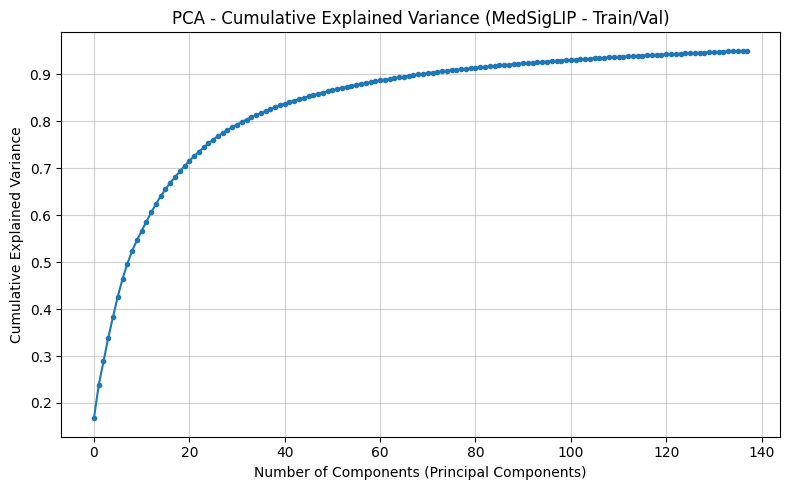

In [4]:
import torch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 你的实际文件路径
file_path = r"\\cabinet\derivatives\cheXpert\FVs_medsiglip"

print("正在使用 PyTorch 加载数据...")
data_dict = torch.load(file_path, map_location='cpu', weights_only=False)

print("\n--- 🔍 解析多层字典结构 ---")
# 提取训练集/验证集字典
train_val_dict = data_dict['train_val']
print(f"已进入 'train_val'，该子字典包含 {len(train_val_dict)} 个键。")

X_train = None
feature_key_name = ""

# 尝试情况 A: 字典里有特定的键 (比如 {'image_paths': [...], 'features': [...]})
for key, value in train_val_dict.items():
    if hasattr(value, 'shape') and len(value.shape) >= 2:
        print(f"⭐ 在 'train_val' 中成功锁定特征矩阵: '{key}'，形状: {value.shape}")
        X_train = value
        feature_key_name = key
        if torch.is_tensor(X_train):
            X_train = X_train.numpy()
        break

# 尝试情况 B: 字典是 {文件名: 特征向量} 的映射格式
if X_train is None:
    sample_value = next(iter(train_val_dict.values()))
    if isinstance(sample_value, (np.ndarray, torch.Tensor)):
        print("检测到 {文件名: 特征向量} 格式，正在自动拼接特征...")
        values_list = [v.numpy() if torch.is_tensor(v) else v for v in train_val_dict.values()]
        X_train = np.vstack(values_list)

if X_train is None:
    raise ValueError("在 'train_val' 里还是没找到矩阵，见鬼了！")

# 确保数据是标准的二维矩阵
if len(X_train.shape) > 2:
    print(f"正在将特征展平为 2 维矩阵...")
    X_train = X_train.reshape(X_train.shape[0], -1)

print(f"✅ 成功提取核心特征矩阵！最终用于 PCA 的数据维度为: {X_train.shape}")


# --- 2. 开始进行 PCA 分析 ---
print("\n正在进行数据标准化 (均值为0，方差为1)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# n_components=0.95 表示保留原始数据 95% 的方差信息
n_components = 0.95 
print(f"正在计算 PCA (目标保留方差: {n_components * 100}%)...")

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print("\n🎉 PCA 降维圆满完成！")
print(f"原始特征维度: {X_train.shape[1]}")
print(f"降维后特征维度: {X_pca.shape[1]}")
print(f"前 5 个主成分解释的方差比例: {np.round(pca.explained_variance_ratio_[:5], 4)}")

# --- 3. 可视化：累积解释方差图 ---
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='.', linestyle='-')
plt.xlabel('Number of Components (Principal Components)')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance (MedSigLIP - Train/Val)')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()